In [1]:
import matplotlib.pyplot as plt
import numpy as np
import graph_style as gs
from scipy.optimize import curve_fit
from matplotlib.ticker import FormatStrFormatter
import fig_helper as fh

gs.set_graph_style(1.0)


In [2]:

date = "2024-12-13"
rid = 11740

data_dict = fh.load_data(rid, date)


In [6]:

delays0 = np.array(data_dict["datasets"][f"ndscan.rid_{rid}.points.axis_0"]) * 1000
freqs = np.array(data_dict["datasets"][f"ndscan.rid_{rid}.points.axis_1"])
flop_durations = np.array(
    data_dict["datasets"][f"ndscan.rid_{rid}.points.channel__axis_0"]
)
nbar = np.array(data_dict["datasets"][f"ndscan.rid_{rid}.points.channel__nbar"])
nbar_err = np.array(data_dict["datasets"][f"ndscan.rid_{rid}.points.channel__nbar_err"])
np.array(data_dict["datasets"][f"ndscan.rid_{rid}.points.channel__spec"])

# Chose all entries with delays1 = f_ax
f_ax = 1.07
delays0 = delays0[freqs == f_ax]
nbar = nbar[freqs == f_ax]
nbar_err = nbar_err[freqs == f_ax]

def linear_func(x, a, b):
    return a * x + b
p_fit, p_cov = curve_fit(linear_func, delays0, nbar)

ndot = p_fit[0] * 1000
ndot_err = np.sqrt(p_cov[0][0]) * 1000
print(ndot)
print(ndot_err)


33.27630912626012
3.2213698520076246


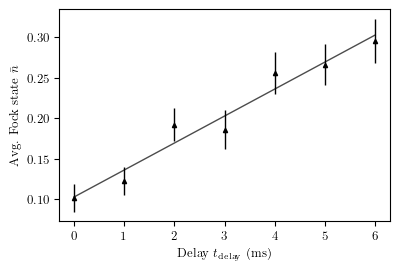

: 

In [ ]:
fig_width = gs.get_fig_width()*2/3
fig_height = fig_width * 2/3
fig, ax = plt.subplots(figsize=(fig_width, fig_height), constrained_layout=True)
c = "k"
ax.errorbar(delays0, nbar, yerr=nbar_err, zorder=11, fmt="^", color=c, elinewidth=1.0)
ax.plot(
    delays0,
    linear_func(delays0, *p_fit),
    label="linear heating fit",
    alpha=gs.get_alpha(),
    color=c,
    zorder=10,
    ls="-",
)
textstr = f"Heating rate = {ndot:.0f}({ndot_err:.0f}) q/s"

# ax.text(
#     0.05,
#     0.95,
#     textstr,
#     transform=ax.transAxes,
#     verticalalignment="top",
#     horizontalalignment="left",
#     fontsize=,
# )
ax.set_xlabel("Delay $t_{\\rm delay}$ (ms)")
ax.set_ylabel("Avg. Fock state $\\bar{n}$")
ax.grid(None)

f_name = "..\\..\\pdf_figure\\ch4\\heating_rate.pdf"
plt.savefig(f_name)